In [3]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv(r"C:\Users\Client\Downloads\churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Data Cleaning

In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [11]:
df = df.dropna()

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

EDA (Exploratary Data Analysis)

In [14]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [15]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

In [16]:
pd.crosstab(df['gender'], df['Churn'])

Churn,No,Yes
gender,,
Female,2544,939
Male,2619,930


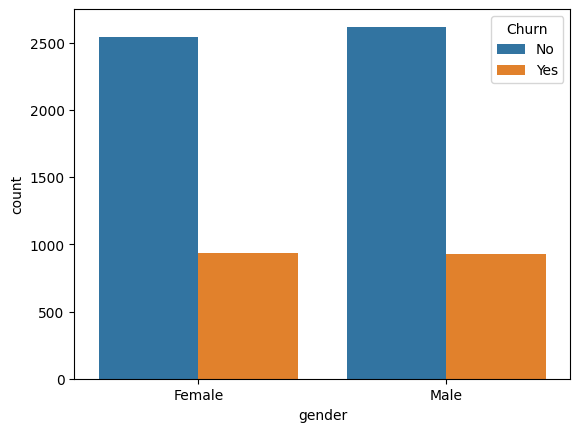

In [17]:
sns.countplot(x='gender', hue='Churn', data=df)
plt.show()

In [18]:
pd.crosstab(df['Contract'], df['Churn'])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


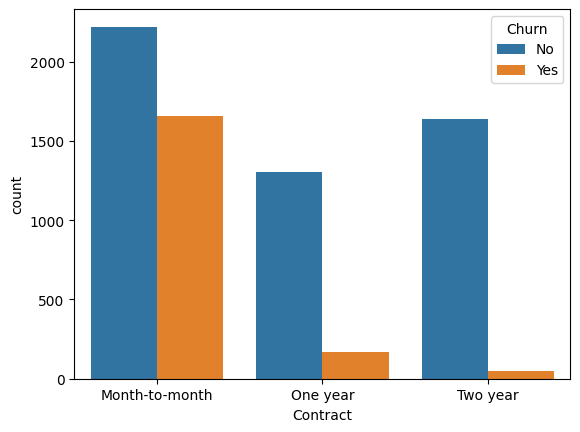

In [19]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.show()

In [20]:
pd.crosstab(df['InternetService'], df['Churn'])

Churn,No,Yes
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


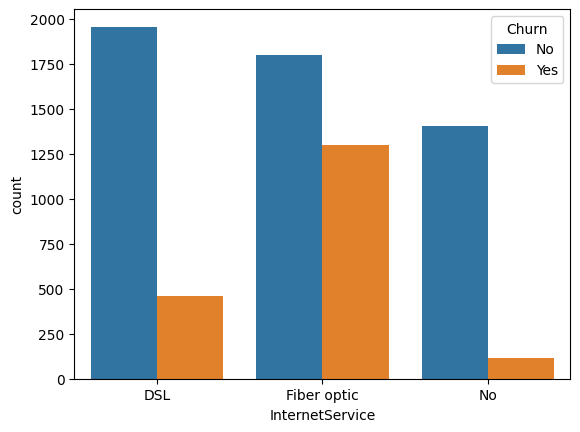

In [21]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.show()

In [22]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

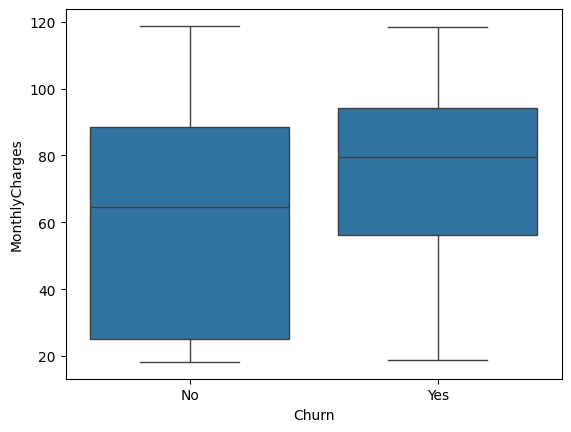

In [23]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

In [24]:
df.groupby('Churn')['tenure'].mean()

Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64

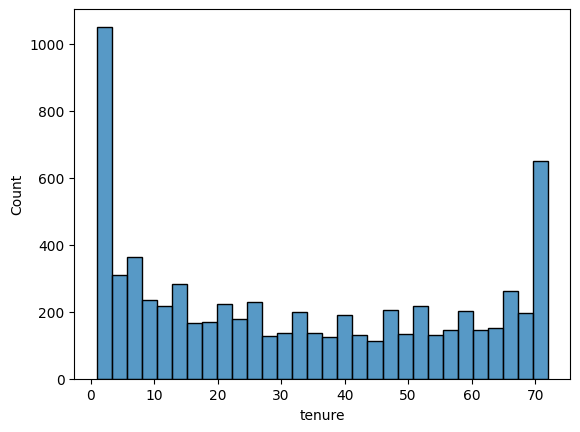

In [25]:
sns.histplot(df['tenure'], bins=30)
plt.show()

In [26]:
pd.crosstab(df['PaymentMethod'], df['Churn'])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


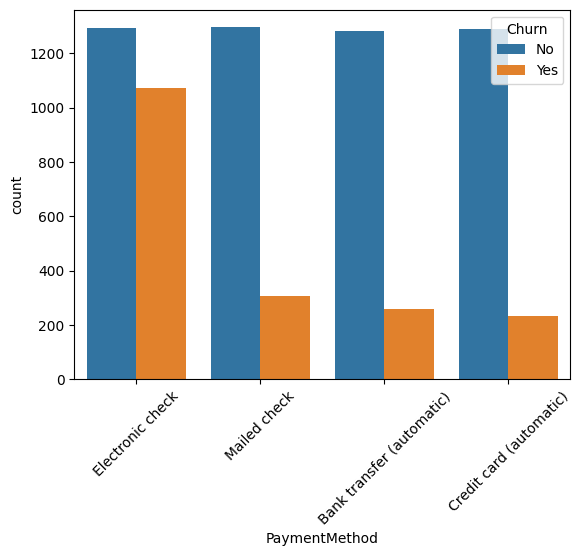

In [27]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.show()

Important Insights

In [28]:
pd.crosstab(df['SeniorCitizen'], df['Churn'])

Churn,No,Yes
SeniorCitizen,,
0,4497,1393
1,666,476


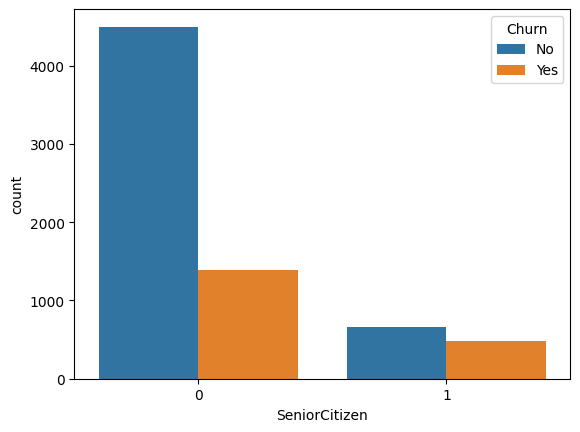

In [29]:
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)
plt.show()

In [30]:
pd.crosstab(df['Partner'], df['Churn'])

Churn,No,Yes
Partner,,
No,2439,1200
Yes,2724,669


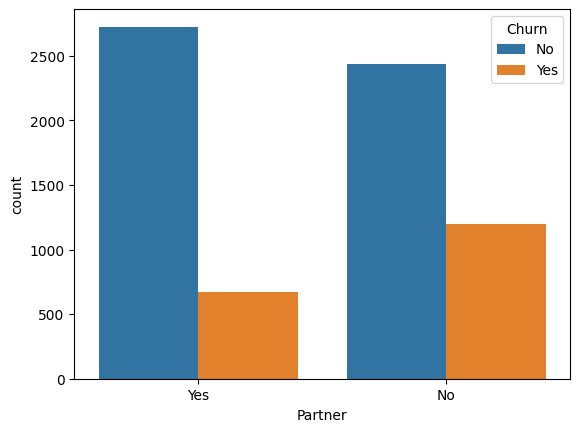

In [31]:
sns.countplot(x='Partner', hue='Churn', data=df)
plt.show()

In [32]:
pd.crosstab(df['Dependents'], df['Churn'])

Churn,No,Yes
Dependents,,
No,3390,1543
Yes,1773,326


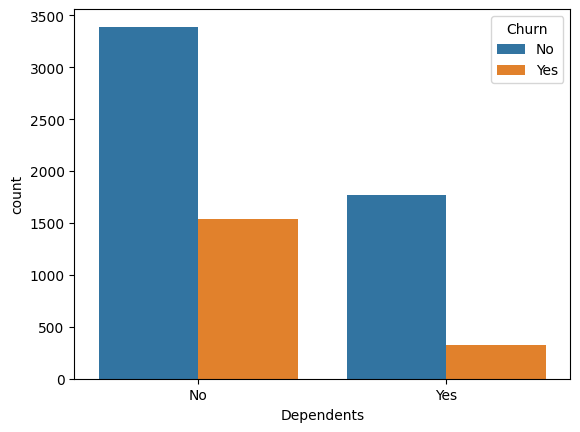

In [33]:
sns.countplot(x='Dependents', hue='Churn', data=df)
plt.show()

In [34]:
df.groupby('Contract')['MonthlyCharges'].mean()

Contract
Month-to-month    66.398490
One year          65.079416
Two year          60.872374
Name: MonthlyCharges, dtype: float64

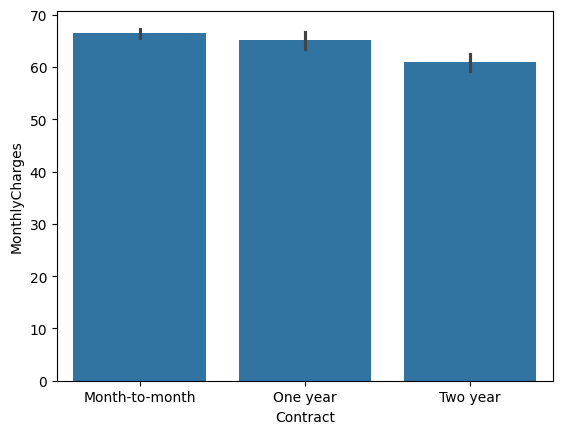

In [35]:
sns.barplot(x='Contract', y='MonthlyCharges', data=df)
plt.show()

In [36]:
df.groupby('Contract')['TotalCharges'].sum()

Contract
Month-to-month    5305861.5
One year          4467053.5
Two year          6283253.7
Name: TotalCharges, dtype: float64

In [37]:
churn_rate = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()*100
print(churn_rate)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665


In [38]:
df.to_csv("churn_cleaned.csv", index=False)

In [39]:
import os
os.getcwd()

'C:\\Users\\Client'

In [40]:
os.listdir()

['.anaconda',
 '.cache',
 '.conda',
 '.condarc',
 '.continuum',
 '.cufflinks',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.keras',
 '.matplotlib',
 '.ms-ad',
 '.streamlit',
 '.thumbnails',
 '.Untitled14.ipynb.layout',
 '.virtual_documents',
 '.vscode',
 '3D Objects',
 'adultKNN.ipynb',
 'anaconda3',
 'anaconda_projects',
 'AppData',
 'Application Data',
 'ASHU_ML_EXAM.ipynb',
 'Ashu_Neural_dataset.ipynb',
 'attrition,inclusive,churn.ipynb',
 'bank customer churn.ipynb',
 'benglaure house ,pp.ipynb',
 'blood pressure.ipynb',
 'bloodpressure abnormality.ipynb',
 'bloodpressure.ipynb',
 'Churn Project.ipynb',
 'churn_cleaned.csv',
 'CNN model mnist_train.ipynb',
 'Contacts',
 'Cookies',
 'cr.ipynb',
 'credit risk.ipynb',
 'ctg.ipynb',
 'customer shopping plots.ipynb',
 'DBSCAN .ipynb',
 'Documents',
 'dogcat.ipynb',
 'Downloads',
 'Embeddings.ipynb',
 'exam .ipynb',
 'exam.ipynb',
 'Favorites',
 'FEATURE OVER SAMPLING.ipynb',
 'firstclass.java',
 'h1n1.ipynb',
 'hard.ipynb',
 'hie